# 06. 순환신경망 (RNN)

In [ ]:
%%capture
!pip install JAEN transformers -qU

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchinfo import summary

# device 설정 (GPU가 사용 가능하면 GPU로, 그렇지 않으면 CPU 사용)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

## 06-001 Tokenizer 불러오기


In [ ]:
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained("bert-base-cased")

/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

## 06-002 토큰화 실습


In [ ]:
tokenizer("AI Essential")

{'input_ids': [101, 19016, 26768, 102], 'token_type_ids': [0, 0, 0, 0], 'attention_mask': [1, 1, 1, 1]}

## 06-003 토큰화된 텍스트 확인


In [ ]:
tokens = tokenizer.tokenize("AI Essential")
tokens

['AI', 'Essential']

## 06-004 토큰을 ID로 변환


In [ ]:
ids = tokenizer.convert_tokens_to_ids(tokens)
ids

[19016, 26768]

## 06-005 토큰 ID를 텍스트로 디코딩


In [ ]:
tokenizer.decode(ids)

'AI Essential'

## 06-006 임베딩 모듈 생성 및 사용


In [ ]:
import torch
import torch.nn as nn

# 임베딩 모듈 생성 (정수 인덱스 10개, 각 인덱스는 5차원의 벡터로 매핑)
embedding_layer = nn.Embedding(num_embeddings=10, embedding_dim=5)

# 임베딩에 사용할 예시 입력 데이터 (정수 인덱스)
# 여기서 [2, 5, 7]은 단어나 토큰에 해당한다고 가정
input_data = torch.tensor([2, 5, 7])

# 임베딩 레이어에 입력 데이터를 전달하여 벡터 변환
embedded_output = embedding_layer(input_data)

print("입력 데이터 (정수 인덱스):", input_data)
print("임베딩 결과 (벡터):\n", embedded_output)

입력 데이터 (정수 인덱스): tensor([2, 5, 7])
임베딩 결과 (벡터):
 tensor([[ 0.0036, -0.2073,  2.8095,  0.2415, -0.7481],
        [ 0.0180, -1.3249, -0.0496, -0.3427,  0.5183],
        [-0.4125, -0.3788, -2.4944,  0.8009,  0.0683]],
       grad_fn=<EmbeddingBackward0>)


## 06-007 코퍼스 및 레이블 정의


In [ ]:
corpus = [
    'very good nice quality',
    'stop lying',
    'ugly terrible',
    'excellent work',
    'adorable lovely',
    'bad',
    'great nice'
]
y = torch.FloatTensor([1, 0, 0, 1, 1, 0, 1]).reshape(-1, 1)  # 0: 부정, 1: 긍정

## 06-008 교육용 토크나이저로 문장 변환


In [ ]:
from transformers import AutoTokenizer

# 교육용 토크나이저 불러오기
tokenizer = AutoTokenizer.from_pretrained(
    'gmteacher/simple-word-tokenizer',
    clean_up_tokenization_spaces=True)
seqs = tokenizer(corpus)['input_ids']
seqs  # 변환된 시퀀스

tokenizer_config.json:   0%|          | 0.00/560 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/977 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/51.0 [00:00<?, ?B/s]

[[14, 6, 2, 10], [11, 9], [13, 12], [5, 15], [3, 8], [4], [7, 2]]

## 06-009 토큰 ID를 단어로 복원


In [ ]:
# 시퀀스를 단어로 복원
[tokenizer.decode(seq) for seq in seqs]

['very good nice quality',
 'stop lying',
 'ugly terrible',
 'excellent work',
 'adorable lovely',
 'bad',
 'great nice']

## 06-010 시퀀스를 텐서로 변환하고 패딩


In [ ]:
from torch.nn.utils.rnn import pad_sequence

# 각 시퀀스를 텐서로 변환
seqs = [torch.tensor(seq) for seq in seqs]

# 패딩
x = pad_sequence(seqs, batch_first=True)
x

tensor([[14,  6,  2, 10],
        [11,  9,  0,  0],
        [13, 12,  0,  0],
        [ 5, 15,  0,  0],
        [ 3,  8,  0,  0],
        [ 4,  0,  0,  0],
        [ 7,  2,  0,  0]])

## 06-011 텍스트 분류기 모델 정의


In [ ]:
class TextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, seq_len, num_class):
        super().__init__()
        # 임베딩 계층 추가
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.flat = nn.Flatten()
        self.fc = nn.Linear(embed_dim*seq_len, num_class)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out = self.embedding(x)
        out = self.flat(out)
        out = self.fc(out)
        out = self.sigmoid(out)
        return out

## 06-012 텍스트 분류기 모델 인스턴스 생성 및 출력 테스트


In [ ]:
torch.manual_seed(0)
# 모델 인스턴스 생성
model = TextClassifier(tokenizer.vocab_size, 2, x.shape[1], 1).to(device)

# 출력 테스트
output = model(x[:1].to(device))
output.shape

torch.Size([1, 1])

## 06-013 장치 적용


In [ ]:
# 장치 적용
x = x.to(device)
y = y.to(device)

## 06-014 모델 학습 및 손실 계산


In [ ]:
loss_fn = nn.BCELoss()  # 손실 함수
optimizer = optim.Adam(model.parameters())  # 최적화 도구(optimizer)

epochs = 30000  # 최대 에폭 지정
results = {'cost':[]}

model.train()  # 학습 모드 설정

for epoch in range(epochs):
    h = model(x)  # 예측 값 생성(추론)
    loss = loss_fn(h, y)  # 손실 계산

    optimizer.zero_grad()  # 미분 값 초기화
    loss.backward()  # 역전파(미분 계산)
    optimizer.step()  # 업데이트 진행

    results['cost'].append(loss.item())

    if epoch % 1000 == 0:
        print(f'epoch: {epoch:4d}, cost: {results["cost"][-1]:.10f}')

epoch:    0, cost: 0.8336125612
epoch: 1000, cost: 0.0999854431
epoch: 2000, cost: 0.0096470183
epoch: 3000, cost: 0.0027971682
epoch: 4000, cost: 0.0011345365
epoch: 5000, cost: 0.0005321922
epoch: 6000, cost: 0.0002693047
epoch: 7000, cost: 0.0001423986
epoch: 8000, cost: 0.0000773963
epoch: 9000, cost: 0.0000428017
epoch: 10000, cost: 0.0000239753
epoch: 11000, cost: 0.0000135434
epoch: 12000, cost: 0.0000076884
epoch: 13000, cost: 0.0000043999
epoch: 14000, cost: 0.0000025218
epoch: 15000, cost: 0.0000014369
epoch: 16000, cost: 0.0000008620
epoch: 17000, cost: 0.0000004852
epoch: 18000, cost: 0.0000002816
epoch: 19000, cost: 0.0000001721
epoch: 20000, cost: 0.0000000771
epoch: 21000, cost: 0.0000000630
epoch: 22000, cost: 0.0000000118
epoch: 23000, cost: 0.0000000059
epoch: 24000, cost: 0.0000000033
epoch: 25000, cost: 0.0000000019
epoch: 26000, cost: 0.0000000012
epoch: 27000, cost: 0.0000000007
epoch: 28000, cost: 0.0000000005
epoch: 29000, cost: 0.0000000003


## 06-015 예측 값을 클래스로 변환


In [ ]:
# 예측 값 생성
h = model(x)

# 예측 값(시그모이드 값)을 클래스로 변환
pred = (h.reshape(-1).detach().cpu() > 0.5).to(torch.float32)

print(f'실제 값: {y.reshape(-1)}')
print(f'예측 값: {pred}')

실제 값: tensor([1., 0., 0., 1., 1., 0., 1.])
예측 값: tensor([1., 0., 0., 1., 1., 0., 1.])


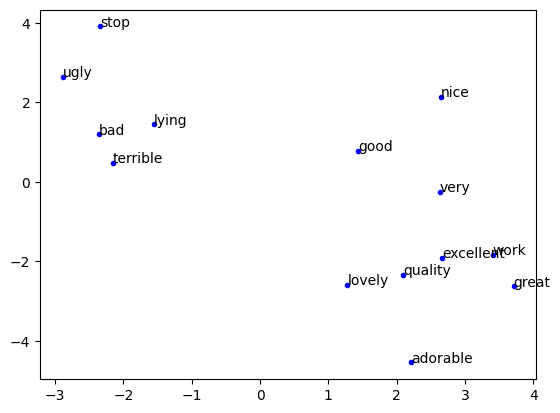

In [ ]:
# 학습 후 임베딩 결과
import matplotlib.pyplot as plt
weights = model.embedding.weight.detach().cpu().numpy()

for idx in range(2, len(tokenizer.vocab)):
    d1, d2 = weights[idx]
    plt.plot(d1, d2, 'b.')
    plt.annotate(tokenizer.decode(idx), (d1, d2))

In [ ]:
# 학습 전 임베딩
model2 = TextClassifier(tokenizer.vocab_size, 2, x.shape[1], 1).to(device)
weights = model2.embedding.weight.detach().cpu().numpy()

for idx in range(2, len(tokenizer.vocab)):
    d1, d2 = weights[idx]
    plt.plot(d1, d2, 'b.')
    plt.annotate(tokenizer.decode(idx), (d1, d2))

## 06-016 코퍼스 및 레이블 정의


In [ ]:
corpus = [
    'very good nice quality',
    'stop lying',
    'ugly terrible',
    'excellent work',
    'adorable lovely',
    'bad',
    'great nice'
]
y = torch.FloatTensor([1, 0, 0, 1, 1, 0, 1]).reshape(-1, 1)  # 0: 부정, 1: 긍정

## 06-017 교육용 토크나이저로 문장 변환


In [ ]:
from transformers import AutoTokenizer

# 교육용 토크나이저 불러오기
tokenizer = AutoTokenizer.from_pretrained(
    'gmteacher/simple-word-tokenizer',
    clean_up_tokenization_spaces=True)
seqs = tokenizer(corpus)['input_ids']
seqs  # 변환된 시퀀스

[[14, 6, 2, 10], [11, 9], [13, 12], [5, 15], [3, 8], [4], [7, 2]]

## 06-018 토큰 ID를 단어로 복원


In [ ]:
# 시퀀스를 단어로 복원
[tokenizer.decode(seq) for seq in seqs]

['very good nice quality',
 'stop lying',
 'ugly terrible',
 'excellent work',
 'adorable lovely',
 'bad',
 'great nice']

## 06-019 시퀀스를 텐서로 변환하고 패딩


In [ ]:
from torch.nn.utils.rnn import pad_sequence

# 각 시퀀스를 텐서로 변환
seqs = [torch.tensor(seq) for seq in seqs]

# 패딩
x = pad_sequence(seqs, batch_first=True)
x

tensor([[14,  6,  2, 10],
        [11,  9,  0,  0],
        [13, 12,  0,  0],
        [ 5, 15,  0,  0],
        [ 3,  8,  0,  0],
        [ 4,  0,  0,  0],
        [ 7,  2,  0,  0]])

## 06-020 텍스트 분류기 모델 정의


In [ ]:
from torch import nn

class TextClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_class):
        super().__init__()
        # 임베딩 계층 추가
        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_size, batch_first=True)
        self.fc = nn.Linear(hidden_size, num_class)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        out = self.embedding(x)
        out, _ = self.lstm(out)
        out = self.fc(out[:, -1, :])
        out = self.sigmoid(out)
        return out

## 06-021 텍스트 분류기 모델 인스턴스 생성 및 출력 테스트


In [ ]:
torch.manual_seed(0)

hidden_size = 128
# 모델 인스턴스 생성
model = TextClassifier(tokenizer.vocab_size, 2, hidden_size, 1).to(device)

# 출력 테스트
output = model(x[:1].to(device))
output.shape

torch.Size([1, 1])

## 06-022 장치 적용


In [ ]:
# 장치 적용
x = x.to(device)
y = y.to(device)

## 06-023 모델 학습 및 손실 계산


In [ ]:
loss_fn = nn.BCELoss()  # 손실 함수
optimizer = optim.Adam(model.parameters())  # 최적화 도구(optimizer)

epochs = 30000  # 최대 에폭 지정
results = {'cost':[]}

model.train()  # 학습 모드 설정

for epoch in range(epochs):
    h = model(x)  # 예측 값 생성(추론)
    loss = loss_fn(h, y)  # 손실 계산

    optimizer.zero_grad()  # 미분 값 초기화
    loss.backward()  # 역전파(미분 계산)
    optimizer.step()  # 업데이트 진행

    results['cost'].append(loss.item())

    if epoch % 1000 == 0:
        print(f'epoch: {epoch:4d}, cost: {results["cost"][-1]:.10f}')

epoch:    0, cost: 0.6917895079
epoch: 1000, cost: 0.0000208432
epoch: 2000, cost: 0.0000062807
epoch: 3000, cost: 0.0000028365
epoch: 4000, cost: 0.0000014922
epoch: 5000, cost: 0.0000008461
epoch: 6000, cost: 0.0000005104
epoch: 7000, cost: 0.0000002860
epoch: 8000, cost: 0.0000001666
epoch: 9000, cost: 0.0000000925
epoch: 10000, cost: 0.0000000727
epoch: 11000, cost: 0.0000000388
epoch: 12000, cost: 0.0000000298
epoch: 13000, cost: 0.0000000080
epoch: 14000, cost: 0.0000000052
epoch: 15000, cost: 0.0000000034
epoch: 16000, cost: 0.0000000022
epoch: 17000, cost: 0.0000000014
epoch: 18000, cost: 0.0000000010
epoch: 19000, cost: 0.0000000007
epoch: 20000, cost: 0.0000000004
epoch: 21000, cost: 0.0000000003
epoch: 22000, cost: 0.0000000002
epoch: 23000, cost: 0.0000000001
epoch: 24000, cost: 0.0000000001
epoch: 25000, cost: 0.0000000001
epoch: 26000, cost: 0.0000000000
epoch: 27000, cost: 0.0000000000
epoch: 28000, cost: 0.0000000000
epoch: 29000, cost: 0.0000000000


## 06-024 예측 값을 클래스로 변환


In [ ]:
# 예측 값(시그모이드 값)을 클래스로 변환
pred = (h.reshape(-1).detach().cpu() > 0.5).to(torch.float32)

print(f'실제 값: {y.reshape(-1)}')
print(f'예측 값: {pred}')

실제 값: tensor([1., 0., 0., 1., 1., 0., 1.])
예측 값: tensor([1., 0., 0., 1., 1., 0., 1.])


## 연습문제-06-001 10개 문서 유형 분류를 위한 모델 정의 (Module 방식)


In [ ]:
import torch
from torch import nn

# DocumentClassifier 모델 정의
class DocumentClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, num_class=10):
        super().__init__()

        # 1. Embedding 계층: 입력된 단어를 고차원 벡터로 변환합니다. vocab_size, embed_dim 사용 (vocab_size: 단어 사전 크기, embed_dim: 임베딩 차원 수)

        # 2. LSTM 계층: 순차적 데이터를 처리하는 LSTM 계층입니다. embed_dim, hidden_size, batch_first=True 사용 (embed_dim 크기의 입력을 받아 hidden_size 크기의 출력을 반환)

        # 3. Fully Connected Layer (FC): LSTM의 출력을 사용해 문서 유형을 분류하는 계층입니다. hidden_size, num_class 사용 (hidden_size에서 10개의 문서 유형으로 분류)

    def forward(self, x):
        # 4. 입력 데이터 > Embedding 계층

        # 5. Embedding 계층 > LSTM 계층

        # 6. LSTM 계층 > FC 계층 (LSTM의 마지막 타임스텝의 출력을 사용해 FC 계층에 전달)

        # 7. 값 반환


model = DocumentClassifier(vocab_size=10000, embed_dim=128, hidden_size=256)
model(torch.randint(0, 10000, (100, 20))).shape

## 06-025 텍스트 분류 파이프라인 사용


In [ ]:
from transformers import pipeline

classifier = pipeline('text-classification')
classifier("I've been waiting for a HuggingFace course my whole life.")

No model was supplied, defaulted to distilbert/distilbert-base-uncased-finetuned-sst-2-english and revision 714eb0f (https://huggingface.co/distilbert/distilbert-base-uncased-finetuned-sst-2-english).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9598049521446228}]

## 06-026 DistilBERT로 텍스트 분류


In [ ]:
import torch
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification

model_name = "distilbert-base-uncased-finetuned-sst-2-english"
tokenizer = DistilBertTokenizer.from_pretrained(model_name)
model = DistilBertForSequenceClassification.from_pretrained(model_name)

text = "I've been waiting for a HuggingFace course my whole life."
inputs = tokenizer(text, return_tensors="pt")
with torch.no_grad():
    logits = model(**inputs).logits

predicted_class_id = logits.argmax().item()
label = model.config.id2label[predicted_class_id]
score = torch.softmax(logits, dim=1).squeeze()[predicted_class_id].item()
print(f'label:{label}, score:{score}')

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

label:POSITIVE, score:0.9598049521446228


## 06-027 파이프라인 모델 지정 및 예측


In [ ]:
# 파이프라인 모델 지정
classifier = pipeline('text-classification', model=model, tokenizer=tokenizer)
classifier("I've been waiting for a HuggingFace course my whole life.")

Device set to use cpu


[{'label': 'POSITIVE', 'score': 0.9598049521446228}]

## 06-028 여러 문장 분류


In [ ]:
# 여러 문장 분류
classifier(
    ["I've been waiting for a HuggingFace course my whole life.",
     "I hate this so much!"])

[{'label': 'POSITIVE', 'score': 0.9598049521446228},
 {'label': 'NEGATIVE', 'score': 0.9994558691978455}]

## 06-029 한국어 감정 분류


In [ ]:
# 한국어 감정 분류
classifier_ko = pipeline('text-classification', model='matthewburke/korean_sentiment')
classifier_ko(
    ["그녀가 먼저 말을 걸어와서 나는 무척 기뻤다.",
     "듣기 싫어 죽겠네, 짜증나니까 그만 좀 닥쳐줄래"])

config.json:   0%|          | 0.00/887 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/552 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/396k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/788k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu


[{'label': 'LABEL_1', 'score': 0.9496679902076721},
 {'label': 'LABEL_0', 'score': 0.9464049339294434}]

## 06-030 제로 샷 분류


In [ ]:
# zero-shot classification
classifier = pipeline("zero-shot-classification")
classifier(
    "This is a course about the Transformers library",
    candidate_labels=["education", "politics", "business"],
)

No model was supplied, defaulted to facebook/bart-large-mnli and revision d7645e1 (https://huggingface.co/facebook/bart-large-mnli).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/1.15k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.63G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu


{'sequence': 'This is a course about the Transformers library',
 'labels': ['education', 'business', 'politics'],
 'scores': [0.8445994257926941, 0.11197380721569061, 0.04342673346400261]}

## 06-031 한국어 제로 샷 분류


In [ ]:
# 한국어 zero-shot classification
model_name = 'MoritzLaurer/mDeBERTa-v3-base-xnli-multilingual-nli-2mil7'
classifier_ko = pipeline("zero-shot-classification", model_name)
classifier_ko(
    "이 강의는 트랜스포머 라이브러리에 대한 것입니다.",
    candidate_labels=["교육", "정치", "사업"],
)

config.json:   0%|          | 0.00/1.09k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/558M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/467 [00:00<?, ?B/s]

spm.model:   0%|          | 0.00/4.31M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

Device set to use cpu


{'sequence': '이 강의는 트랜스포머 라이브러리에 대한 것입니다.',
 'labels': ['교육', '정치', '사업'],
 'scores': [0.7452647686004639, 0.23510362207889557, 0.019631631672382355]}

## 06-032 한국어 제로 샷 분류 예시


In [ ]:
classifier_ko(
    "이 소총의 유효사거리는 5km를 넘습니다.",
    candidate_labels=["예술", "정치", "군사"],
)

{'sequence': '이 소총의 유효사거리는 5km를 넘습니다.',
 'labels': ['군사', '정치', '예술'],
 'scores': [0.7075017094612122, 0.15997332334518433, 0.13252493739128113]}

## 06-033 한국어 제로 샷 분류 예시


In [ ]:
classifier_ko(
    "선과 색의 조화가 탁월한 그 작품은 과거의 어느 작가의 그것과 닮아 있다.",
    candidate_labels=["예술", "정치", "군사"],
)

{'sequence': '선과 색의 조화가 탁월한 그 작품은 과거의 어느 작가의 그것과 닮아 있다.',
 'labels': ['예술', '군사', '정치'],
 'scores': [0.8367243409156799, 0.08361184597015381, 0.07966375350952148]}

## 06-034 질문-답변 파이프라인 사용


In [ ]:
# Q & A
question_answerer = pipeline("question-answering")
question_answerer(
    question="Where do I work?",
    context="My name is Sylvain and I work at Hugging Face in Brooklyn",
)

No model was supplied, defaulted to distilbert/distilbert-base-cased-distilled-squad and revision 564e9b5 (https://huggingface.co/distilbert/distilbert-base-cased-distilled-squad).
Using a pipeline without specifying a model name and revision in production is not recommended.


config.json:   0%|          | 0.00/473 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/261M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/213k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/436k [00:00<?, ?B/s]

Device set to use cpu


{'score': 0.6949766278266907, 'start': 33, 'end': 45, 'answer': 'Hugging Face'}

## 06-035 한국어 질문-답변 파이프라인 사용


In [ ]:
# 한국어 Q & A
question_answerer = pipeline("question-answering", model='timpal0l/mdeberta-v3-base-squad2')
question_answerer(
    question="홍길동은 어디에 있지?",
    context="홍길동씨는 잠실에 있는 숨겨진 국가정보원 빌딩에서 청소를 하며 살아 가고있다.",
)

config.json:   0%|          | 0.00/879 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.11G [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/453 [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/16.3M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/23.0 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/173 [00:00<?, ?B/s]

Device set to use cpu


{'score': 0.7171657085418701, 'start': 5, 'end': 9, 'answer': ' 잠실에'}

## 06-036 한국어 질문-답변 추가 예시


In [ ]:
question_answerer(
    question="홍길동은 무얼하고 있지?",
    context="홍길동씨는 잠실에 있는 숨겨진 국가정보원 빌딩에서 청소를 하며 살아 가고있다.",
)

{'score': 0.5880115032196045, 'start': 27, 'end': 31, 'answer': ' 청소를'}

## 06-037 GPT 텍스트 생성


In [ ]:
# GPT 텍스트 생성
from transformers import pipeline

generator = pipeline("text-generation", model='gpt2')
generator("In this course, we will teach you how to")

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Device set to use cpu
Setting `pad_token_id` to `eos_token_id`:50256 for open-end generation.


[{'generated_text': 'In this course, we will teach you how to use the C library and the Go protocol. We will also demonstrate the use of this tool in a test.\n\nOnce all the information is in order and you understand what it means then you and'}]

## 06-038 KoGPT 텍스트 생성


In [ ]:
# KoGPT 텍스트 생성
generator = pipeline("text-generation", model='skt/kogpt2-base-v2')
output = generator("감기에 걸리지 않으려면")
print(output[0]['generated_text'])

config.json:   0%|          | 0.00/1.00k [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/513M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.83M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/513M [00:00<?, ?B/s]

Device set to use cpu


감기에 걸리지 않으려면 평소 잘 잠들었다가 오후의 오후에 일어나는 것을 자주 해라.
67년생 무리하면 안된다.
99년생 외출이나 여행을 하는 횟수가 잦아진다.
33년생 내일은 더 큰일이 생긴다.
45년생 운
